Urban Data Science & Smart Cities <br>
URSP688Y Spring 2026<br>
Instructor: Chester Harvey <br>
Urban Studies & Planning <br>
National Center for Smart Growth <br>
University of Maryland

# Demo 6 - Geospatial Data

- Coordinate systems
- Points from XY
- Loading shapefiles and geojsons
- Proximity analysis
    - Measuring distance
    - Buffering
- Overlay analysis
- Spatial joining

## Geospatial data fundamentals
- Basic geometry types:
    - Points
    - Linestrings
    - Polygons

<img alt="points, lines, and polygons" width=500 src="https://datacarpentry.org/organization-geospatial/fig/dc-spatial-vector/pnt_line_poly.png">

- Spatial analysis (with vector data) is just Euclidean geometry (remember the Pythagorean theorem?)

<img alt="pythagorean theorem" width=500 src="https://www.katesmathlessons.com/uploads/1/6/1/0/1610286/published/how-to-use-the-pythagorean-theorem-to-find-distance-between-points-on-coordinate-plane-2.png?1595954050">

# GeoPandas: Package for working with shapefile-like tables (GeoDataFrames)

In Anaconda Prompt (Windows) or Terminal (Mac):
```
conda install geopandas
```

## Geospatial data are everywhere

DC affordable housing: https://opendata.dc.gov/datasets/DCGIS::affordable-housing/about

In [1]:
# Import dependencies
import pandas as pd
import geopandas as gpd

## Make points from CSV

In [2]:
# pd.read_csv() function

housing_projects_df = pd.read_csv('Affordable_Housing.csv')

In [ ]:
housing_projects_df.head().T

In [3]:
# gpd.points_from_xy() function
housing_project_points = gpd.points_from_xy(housing_projects_df["LONGITUDE"], housing_projects_df['LATITUDE'])

In [ ]:
housing_project_points

In [4]:
# gpd.GeoDataFrame() class

housing_project_gdf = gpd.GeoDataFrame(housing_projects_df, geometry=housing_project_points)

In [ ]:
housing_project_gdf.head

<Axes: >

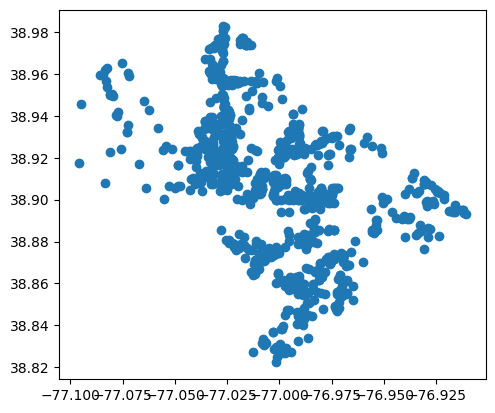

In [5]:
# .plot() method

housing_project_gdf.plot()

## Measuring proximity

### How far is each affordable housing project from Metro Center?

In [ ]:
# Will the distance method provide accurate distances?

# .distance() method

## UTM Zones

[Universal Transverse Mercator](https://en.wikipedia.org/wiki/Universal_Transverse_Mercator_coordinate_system) Zones

The UTM system divides the globe into 120 zones, 60 each in the northern and southern hemispheres. It uses Transverse Mercator projections to minimize shape and distance distortion for localized measurements within each zone.

<img alt="utm slices" width=500 src="https://gisgeography.com/wp-content/uploads/2016/05/UTM-Zones-Globe-2.png">

<img alt="utm standard line" width=500 src="https://gisgeography.com/wp-content/uploads/2016/05/Universe-Transverse-Mercator-Cylinder.png">

1. [What UTM zone am I in?](https://mangomap.com/robertyoung/maps/69585/what-utm-zone-am-i-in-#)
2. [What is the EPSG code for that zone?](https://www.google.com/search?q=epsg+code+for+UTM18N&rlz=1C5GCCM_en&oq=epsg+code+for+UTM18N&gs_lcrp=EgZjaHJvbWUyBggAEEUYOTIHCAEQIRigATIHCAIQIRigATIHCAMQIRigATIHCAQQIRigATIHCAUQIRigATIHCAYQIRiPAjIHCAcQIRiPAtIBCDcxMDJqMGo3qAIAsAIA&sourceid=chrome&ie=UTF-8)

In [ ]:
# Reproject into UTM 18 North, the local UTM zone (EPSG: 32618)

#.to_crs()

In [ ]:
#.plot(column) # Make colorpleth map of distances

In [ ]:
# m = gdf.explore(column='distance_to_metro_center', tiles='CartoDB positron')
# m.save('map.html')

### Which projects are within 1 mile of Metro Center or Columbia Heights?

#### Another approach: Buffer and spatial join

In [ ]:
# Define multiple locations
metro_locations = {
    'Metro Center': {
        'lon': -77.0312124, 
        'lat': 38.898202
    },
    'Columbia Heights': {
        'lon': -77.0350154, 
        'lat': 38.92890
    },
    'Union Station': {
        'lon': -77.0089958, 
        'lat': 38.8984109
    }
}

# Convert to a geodataframe
metro_locations_df = pd.DataFrame.from_dict(metro_locations, orient='index')
metro_locations_points = gpd.points_from_xy(metro_locations_df['lon'], metro_locations_df['lat'])
metro_locations_gdf = gpd.GeoDataFrame(metro_locations_df, geometry=metro_locations_points, crs=4326)
metro_locations_gdf = metro_locations_gdf.to_crs(32618)

In [ ]:
# Buffer metro locations

def miles_to_meters(miles):
    return miles * 1609.34

threshold_dist = miles_to_meters(1) # one mile
metro_locations_buffer = metro_locations_gdf.buffer(threshold_dist)
metro_locations_buffer_gdf = gpd.GeoDataFrame(geometry=metro_locations_buffer, crs=32618)

In [ ]:
# Plot metro buffers and projects together

# ax = metro_locations_buffer_gdf.plot()
# gdf.plot(ax=ax, color='red')

In [ ]:
# Spatially join affordable housing projects to metro buffers

# gpd.sjoin() # function

## Overlay

### How many projects are in each census tract?

- [Population by Tract from Census Reporter](https://censusreporter.org/data/table/?table=B01003&geo_ids=16000US1150000,140|16000US1150000&primary_geo_id=16000US1150000)

In [ ]:
# Load tract polygons from geojson

# gpd.read_file() function

In [ ]:
# Project into local UTM and remove remove record for all of DC

In [ ]:
# Ensure projects and tracts are in the same projection (CRS: coordinate reference system)

# assert (keyword)

In [ ]:
# Spatially join projects to tracts

In [ ]:
# Count unique projects in each tract (groupby, nunique)

In [ ]:
# Join counts onto tracts (tabular join)

In [ ]:
# Calculate projects per population

In [ ]:
# Calcualte units per census tract